# 02 — Turnover Deep Dive

Análise diagnóstica de attrition: **por que as pessoas saem?**

Enquanto o notebook anterior mapeou "quem somos", este investiga o problema central de qualquer operação de People Analytics — a rotatividade. Exploramos as taxas segmentadas, identificamos os drivers de saída e calculamos o impacto financeiro do turnover.

**Objetivo:** Fornecer aos líderes de negócio uma visão clara dos fatores que mais contribuem para a perda de talentos, com recomendações acionáveis para reduzir a attrition.

---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.style.use('dark_background')

COLORS = {
    'primary': '#6366F1', 'secondary': '#8B5CF6', 'accent': '#EC4899',
    'success': '#10B981', 'warning': '#F59E0B', 'danger': '#EF4444',
    'info': '#06B6D4', 'text': '#E2E8F0', 'muted': '#94A3B8',
    'bg': '#0F172A', 'card': '#1E293B', 'grid': '#334155'
}
PALETTE_CAT = ['#6366F1', '#EC4899', '#10B981', '#F59E0B', '#06B6D4', '#8B5CF6', '#EF4444', '#14B8A6', '#F97316']
ATTRITION_COLORS = {'Yes': COLORS['danger'], 'No': COLORS['success']}

plt.rcParams.update({
    'figure.facecolor': COLORS['bg'], 'axes.facecolor': COLORS['card'],
    'axes.edgecolor': COLORS['grid'], 'axes.labelcolor': COLORS['text'],
    'text.color': COLORS['text'], 'xtick.color': COLORS['muted'],
    'ytick.color': COLORS['muted'], 'grid.color': COLORS['grid'],
    'grid.alpha': 0.3, 'font.size': 11, 'axes.titlesize': 14, 'axes.titleweight': 'bold',
})

def format_ax(ax, title='', xlabel='', ylabel='', grid_axis='y'):
    ax.set_title(title, pad=15, loc='left')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    if grid_axis: ax.grid(axis=grid_axis, alpha=0.2, linestyle='--')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

def attrition_rate_by(df, column, ax, title='', top_n=None):
    """Plot attrition rate by a given column."""
    summary = df.groupby(column)['AttritionFlag'].agg(['mean', 'count']).reset_index()
    summary.columns = [column, 'Rate', 'Count']
    summary['Rate'] = summary['Rate'] * 100
    summary = summary.sort_values('Rate', ascending=True)
    if top_n:
        summary = summary.tail(top_n)
    
    colors = [COLORS['danger'] if r > 20 else COLORS['warning'] if r > 15 else COLORS['success'] 
              for r in summary['Rate']]
    bars = ax.barh(summary[column].astype(str), summary['Rate'], color=colors, edgecolor='none', height=0.6)
    for bar, rate, count in zip(bars, summary['Rate'], summary['Count']):
        ax.text(rate + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{rate:.1f}% (n={count:,})', va='center', fontsize=9, color=COLORS['text'])
    
    ax.axvline(df['AttritionFlag'].mean() * 100, color=COLORS['muted'], linestyle='--', alpha=0.5)
    format_ax(ax, title, 'Attrition Rate (%)', '', grid_axis='x')

print('Libraries loaded.')

Libraries loaded.


In [2]:
df = pd.read_csv('../data/processed/master_dataset.csv')

# Quick reference
overall_rate = df['AttritionFlag'].mean() * 100
total = len(df)
attrited = df['AttritionFlag'].sum()
retained = total - attrited

print(f'Total employees: {total:,}')
print(f'Attrited: {attrited:,} ({overall_rate:.1f}%)')
print(f'Retained: {retained:,} ({100-overall_rate:.1f}%)')

Total employees: 4,410
Attrited: 711 (16.1%)
Retained: 3,699 (83.9%)


---
## 2. Attrition Rate — Segmented Analysis

Breaking down attrition across key organizational dimensions to identify **where** the problem is concentrated.

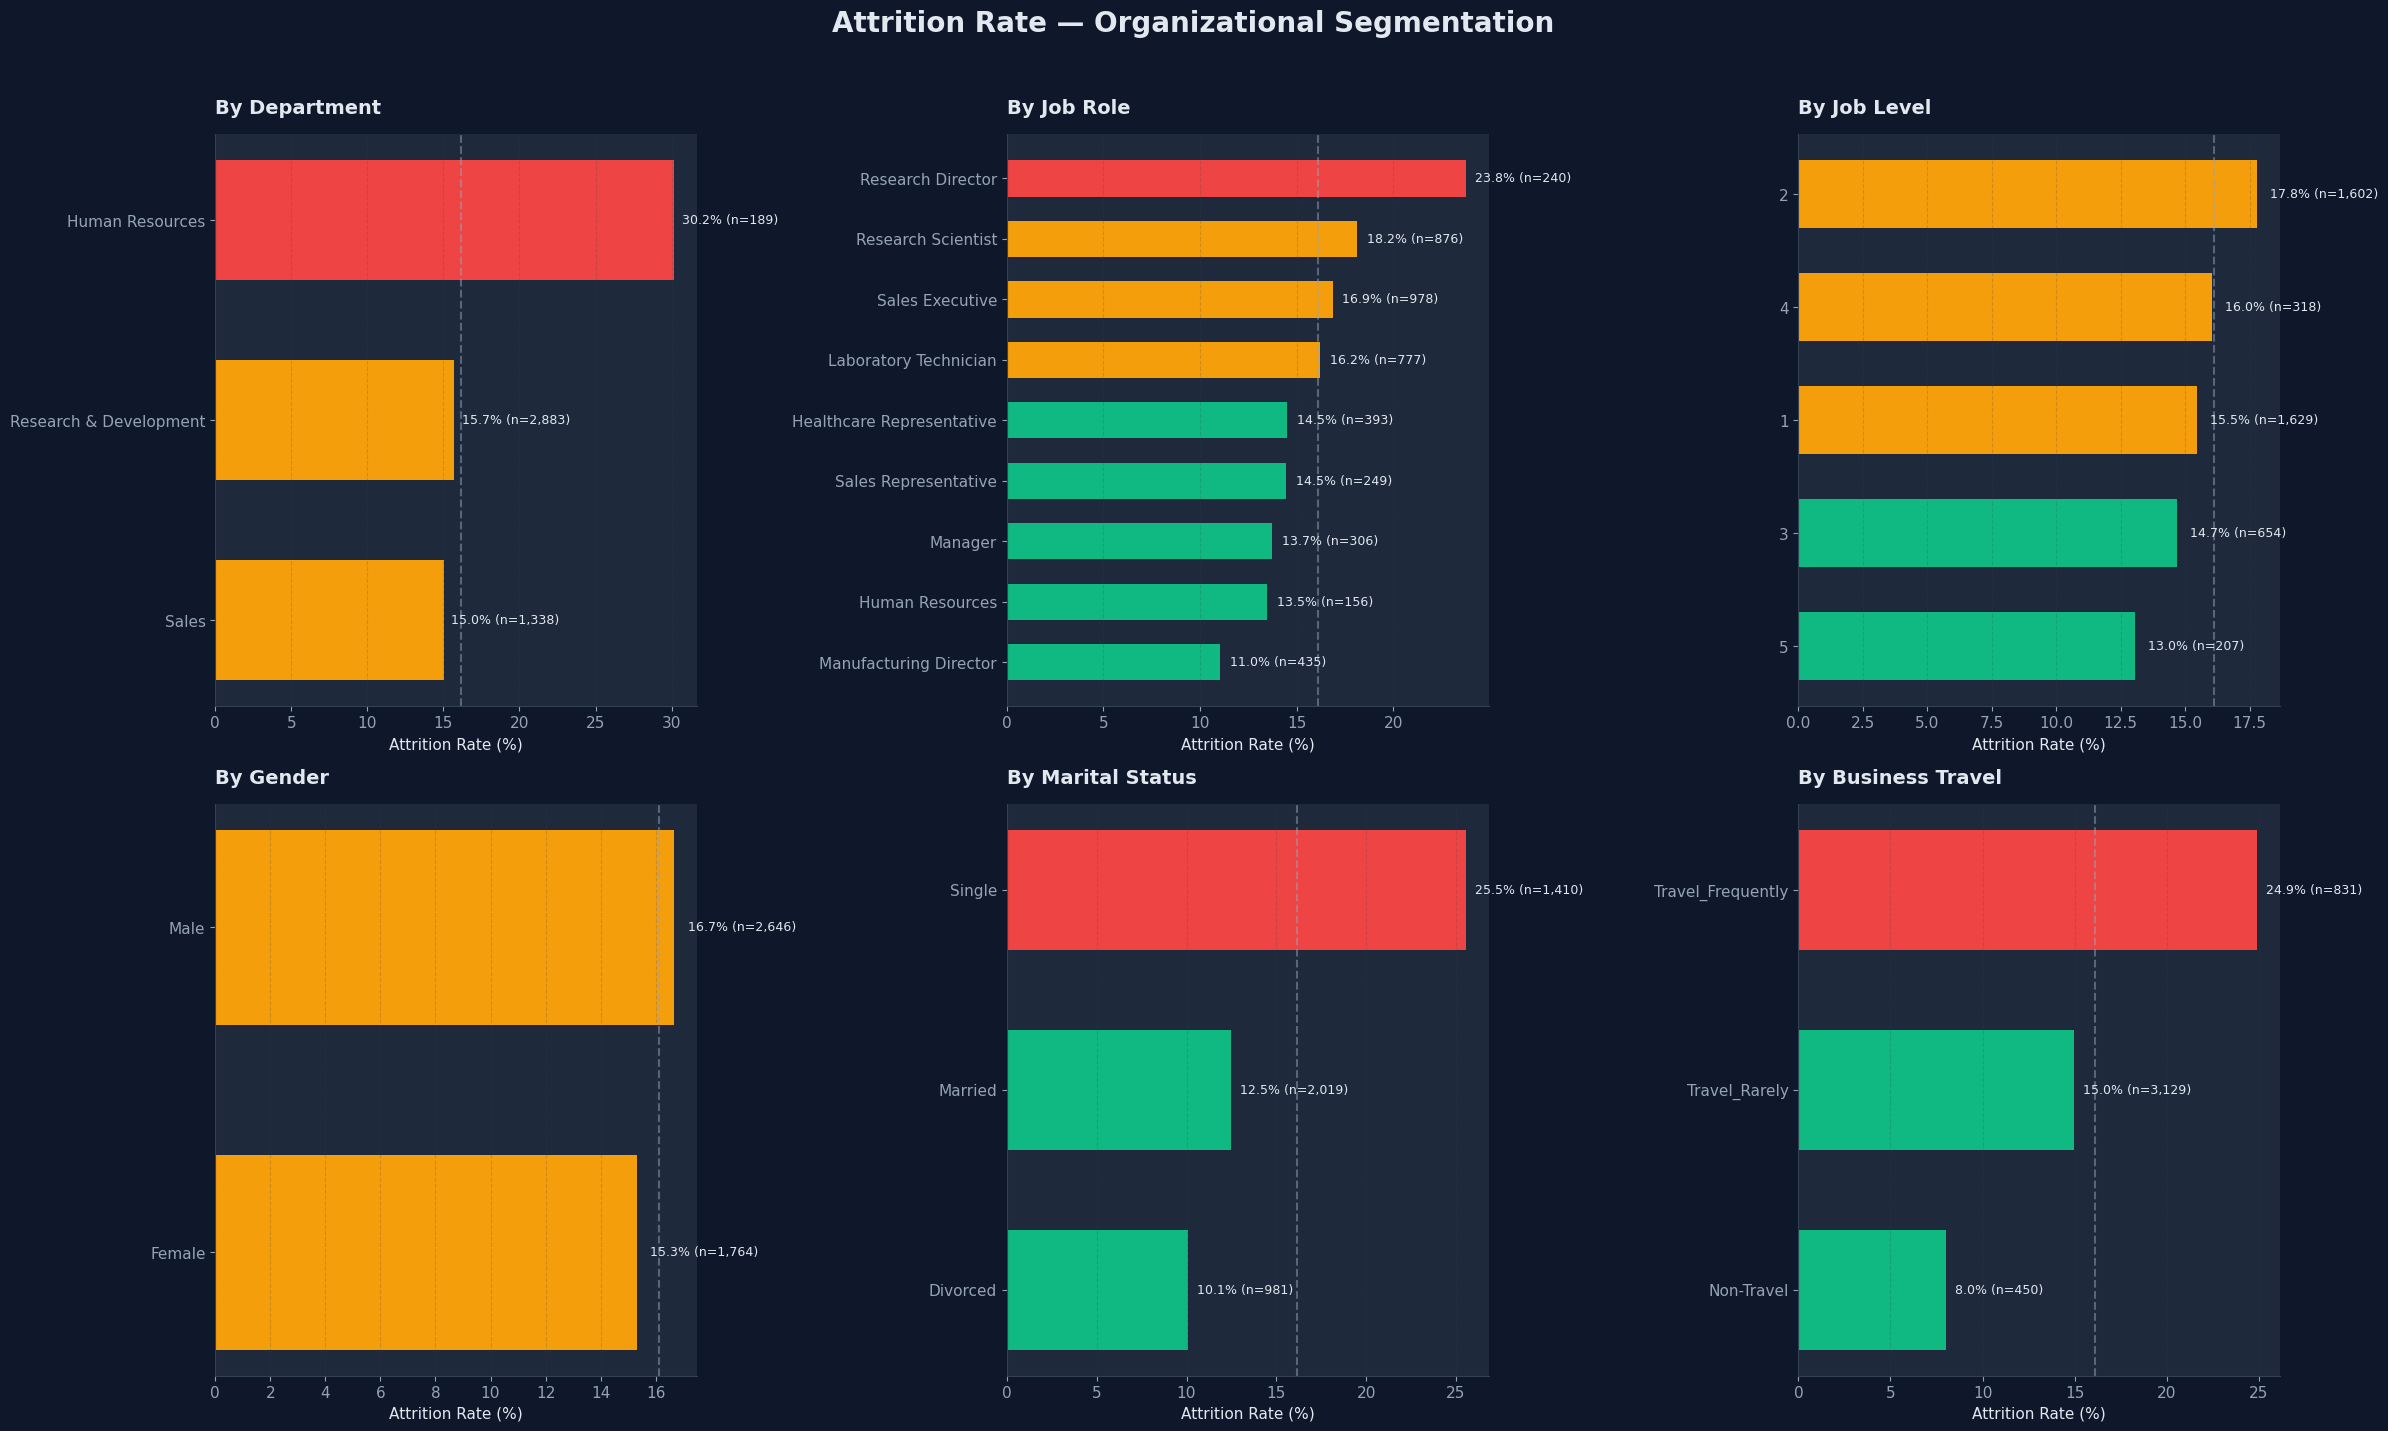

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle('Attrition Rate — Organizational Segmentation', fontsize=20, fontweight='bold', y=1.02)

attrition_rate_by(df, 'Department', axes[0, 0], 'By Department')
attrition_rate_by(df, 'JobRole', axes[0, 1], 'By Job Role')
attrition_rate_by(df, 'JobLevel', axes[0, 2], 'By Job Level')
attrition_rate_by(df, 'Gender', axes[1, 0], 'By Gender')
attrition_rate_by(df, 'MaritalStatus', axes[1, 1], 'By Marital Status')
attrition_rate_by(df, 'BusinessTravel', axes[1, 2], 'By Business Travel')

plt.tight_layout()
plt.savefig('../reports/attrition_segmented.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

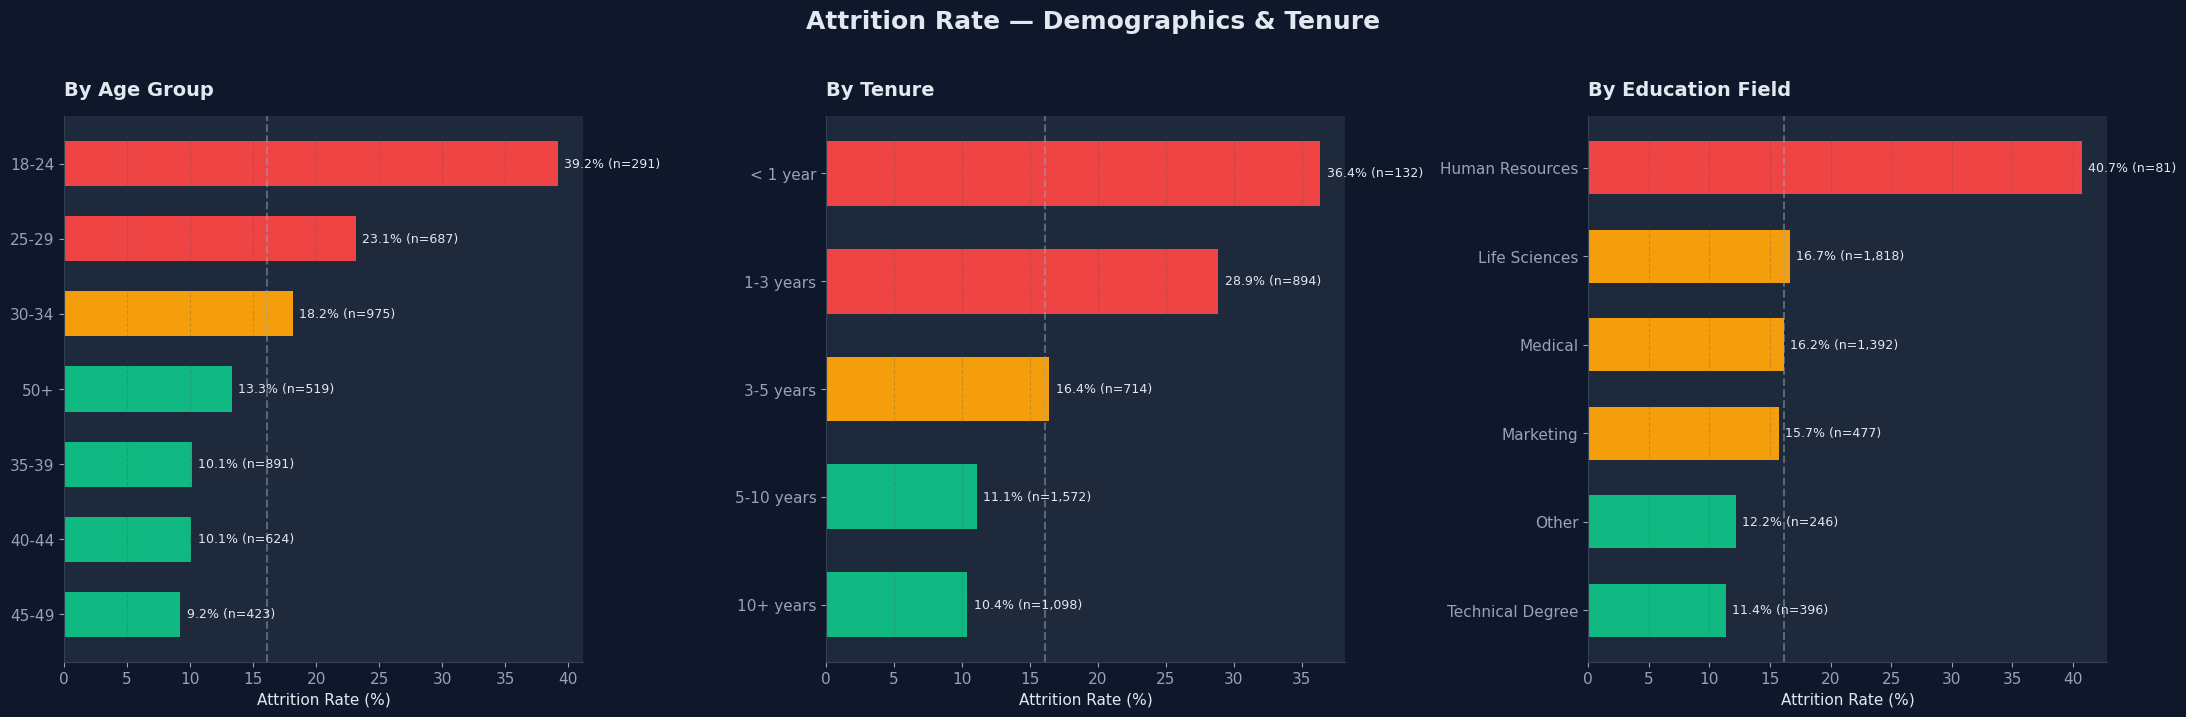

In [4]:
# Age group and tenure segmentation
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Attrition Rate — Demographics & Tenure', fontsize=18, fontweight='bold', y=1.02)

attrition_rate_by(df, 'AgeGroup', axes[0], 'By Age Group')
attrition_rate_by(df, 'TenureGroup', axes[1], 'By Tenure')

# Education field
attrition_rate_by(df, 'EducationField', axes[2], 'By Education Field')

plt.tight_layout()
plt.savefig('../reports/attrition_demographics.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

---
## 3. Risk Factor Analysis

Deep dive into the continuous variables that correlate with attrition.

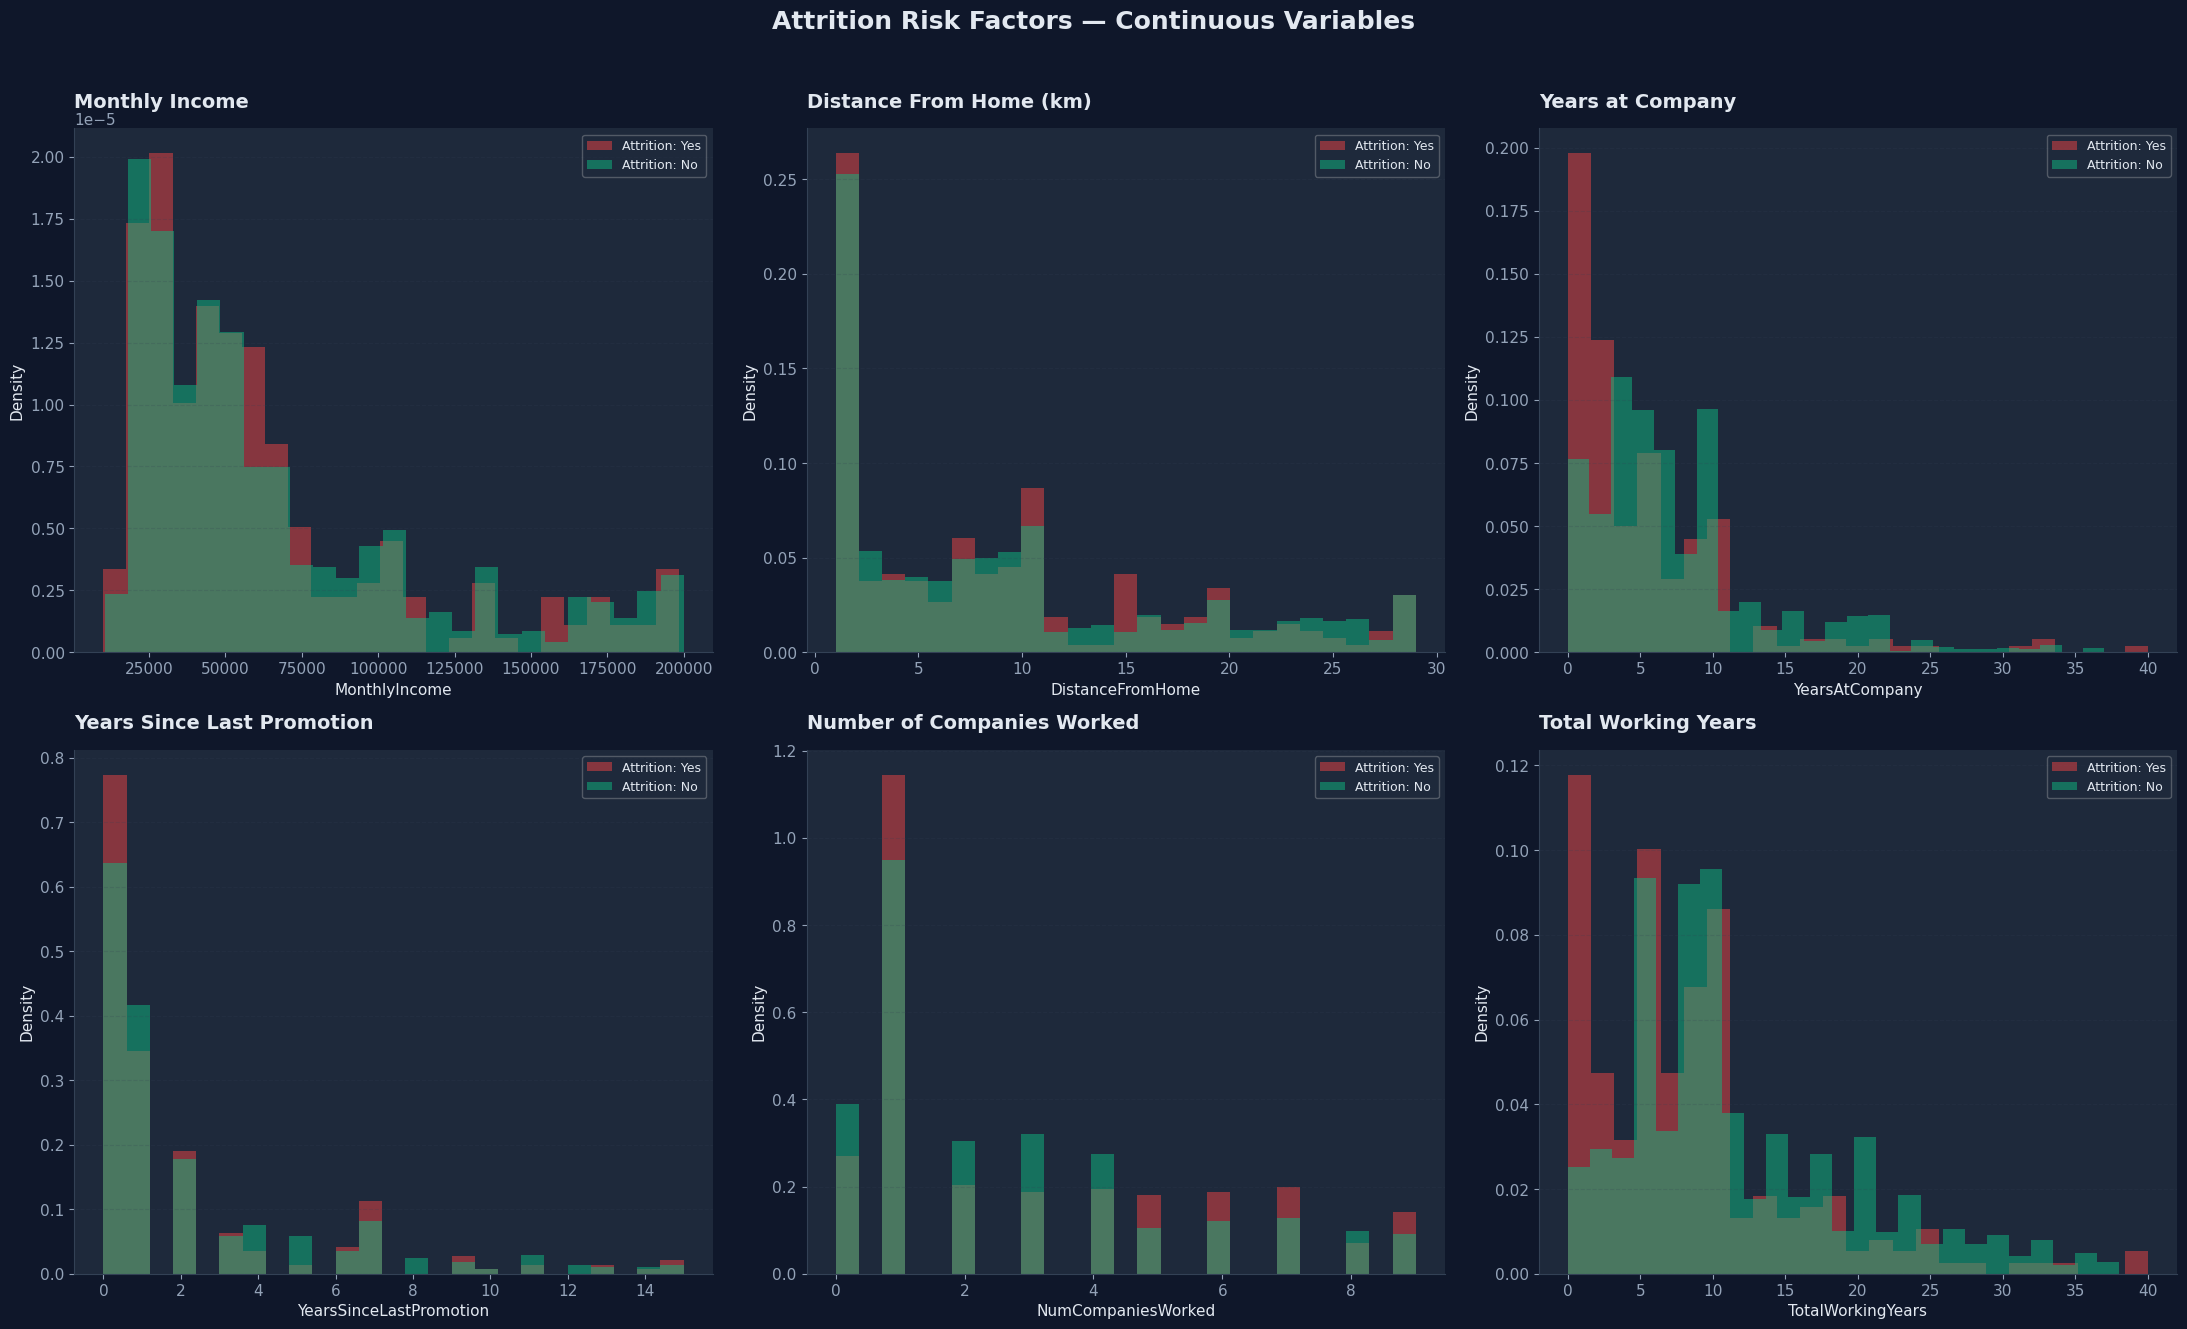

In [5]:
# Attrition vs key continuous variables
fig, axes = plt.subplots(2, 3, figsize=(22, 13))
fig.suptitle('Attrition Risk Factors — Continuous Variables', fontsize=18, fontweight='bold', y=1.02)

risk_vars = [
    ('MonthlyIncome', 'Monthly Income'),
    ('DistanceFromHome', 'Distance From Home (km)'),
    ('YearsAtCompany', 'Years at Company'),
    ('YearsSinceLastPromotion', 'Years Since Last Promotion'),
    ('NumCompaniesWorked', 'Number of Companies Worked'),
    ('TotalWorkingYears', 'Total Working Years')
]

for ax, (var, title) in zip(axes.flat, risk_vars):
    for status, color in ATTRITION_COLORS.items():
        data = df[df['Attrition'] == status][var].dropna()
        ax.hist(data, bins=25, alpha=0.5, color=color, label=f'Attrition: {status}', 
                density=True, edgecolor='none')
    format_ax(ax, title, var, 'Density')
    ax.legend(framealpha=0.3, fontsize=9)

plt.tight_layout()
plt.savefig('../reports/attrition_risk_factors.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

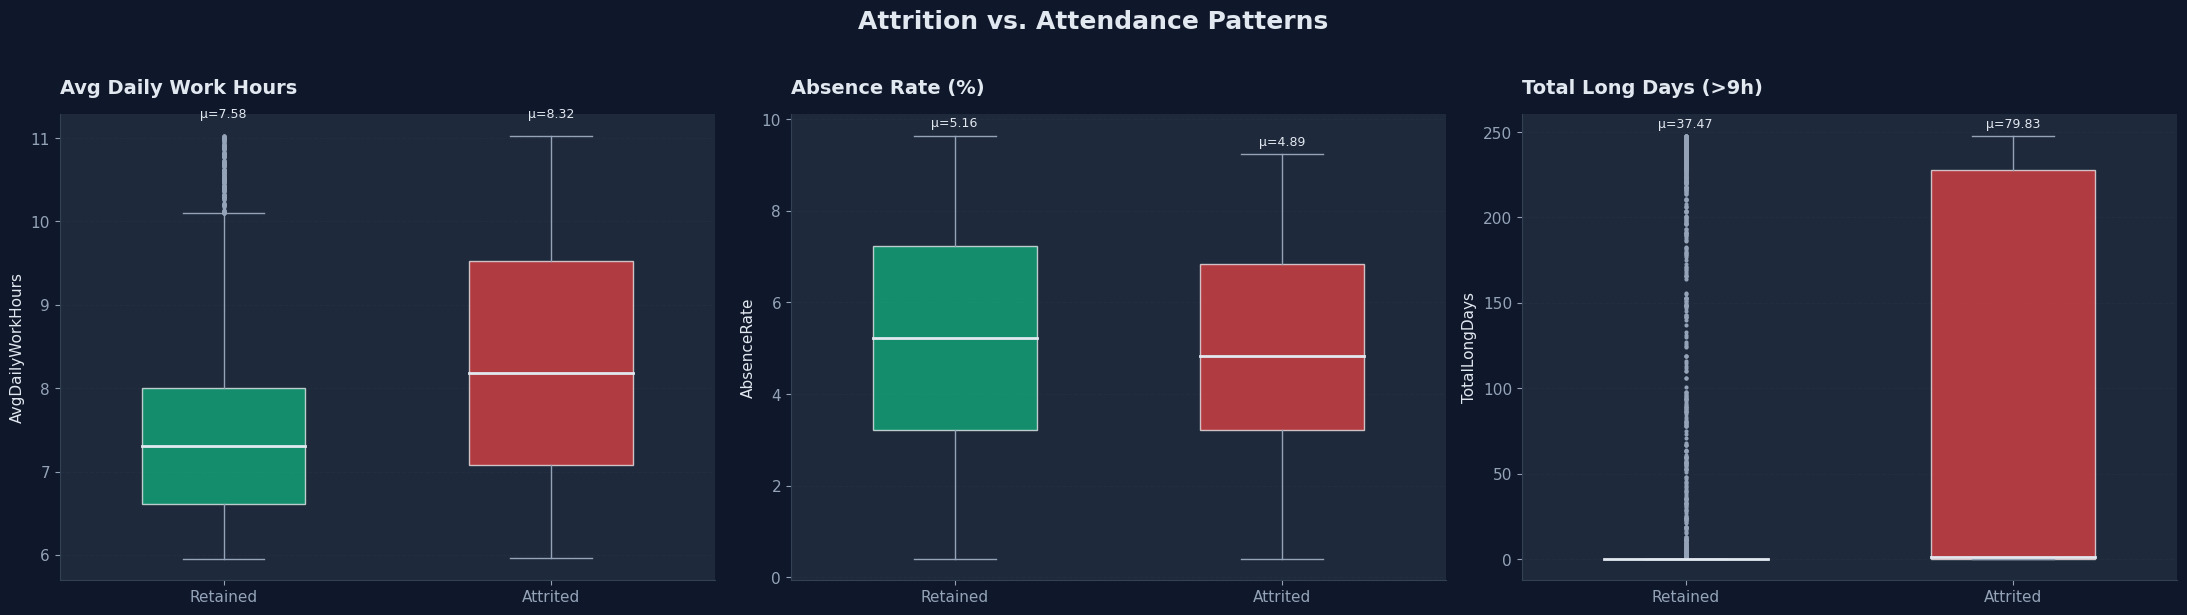

In [6]:
# Attrition vs Attendance metrics
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Attrition vs. Attendance Patterns', fontsize=18, fontweight='bold', y=1.02)

attendance_vars = [
    ('AvgDailyWorkHours', 'Avg Daily Work Hours'),
    ('AbsenceRate', 'Absence Rate (%)'),
    ('TotalLongDays', 'Total Long Days (>9h)')
]

for ax, (var, title) in zip(axes.flat, attendance_vars):
    data_yes = df[df['Attrition'] == 'Yes'][var].dropna()
    data_no = df[df['Attrition'] == 'No'][var].dropna()
    
    bp = ax.boxplot(
        [data_no, data_yes],
        labels=['Retained', 'Attrited'],
        patch_artist=True,
        widths=0.5,
        boxprops=dict(alpha=0.7),
        medianprops=dict(color=COLORS['text'], linewidth=2),
        whiskerprops=dict(color=COLORS['muted']),
        capprops=dict(color=COLORS['muted']),
        flierprops=dict(markerfacecolor=COLORS['muted'], markeredgecolor='none', markersize=3)
    )
    bp['boxes'][0].set_facecolor(COLORS['success'])
    bp['boxes'][1].set_facecolor(COLORS['danger'])
    
    format_ax(ax, title, '', var)
    
    # Add mean annotations
    for i, (data, label) in enumerate([(data_no, 'Retained'), (data_yes, 'Attrited')]):
        ax.text(i + 1, data.max() * 1.02, f'μ={data.mean():.2f}', 
                ha='center', fontsize=9, color=COLORS['text'])

plt.tight_layout()
plt.savefig('../reports/attrition_attendance.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

---
## 4. Satisfaction & Engagement Drivers

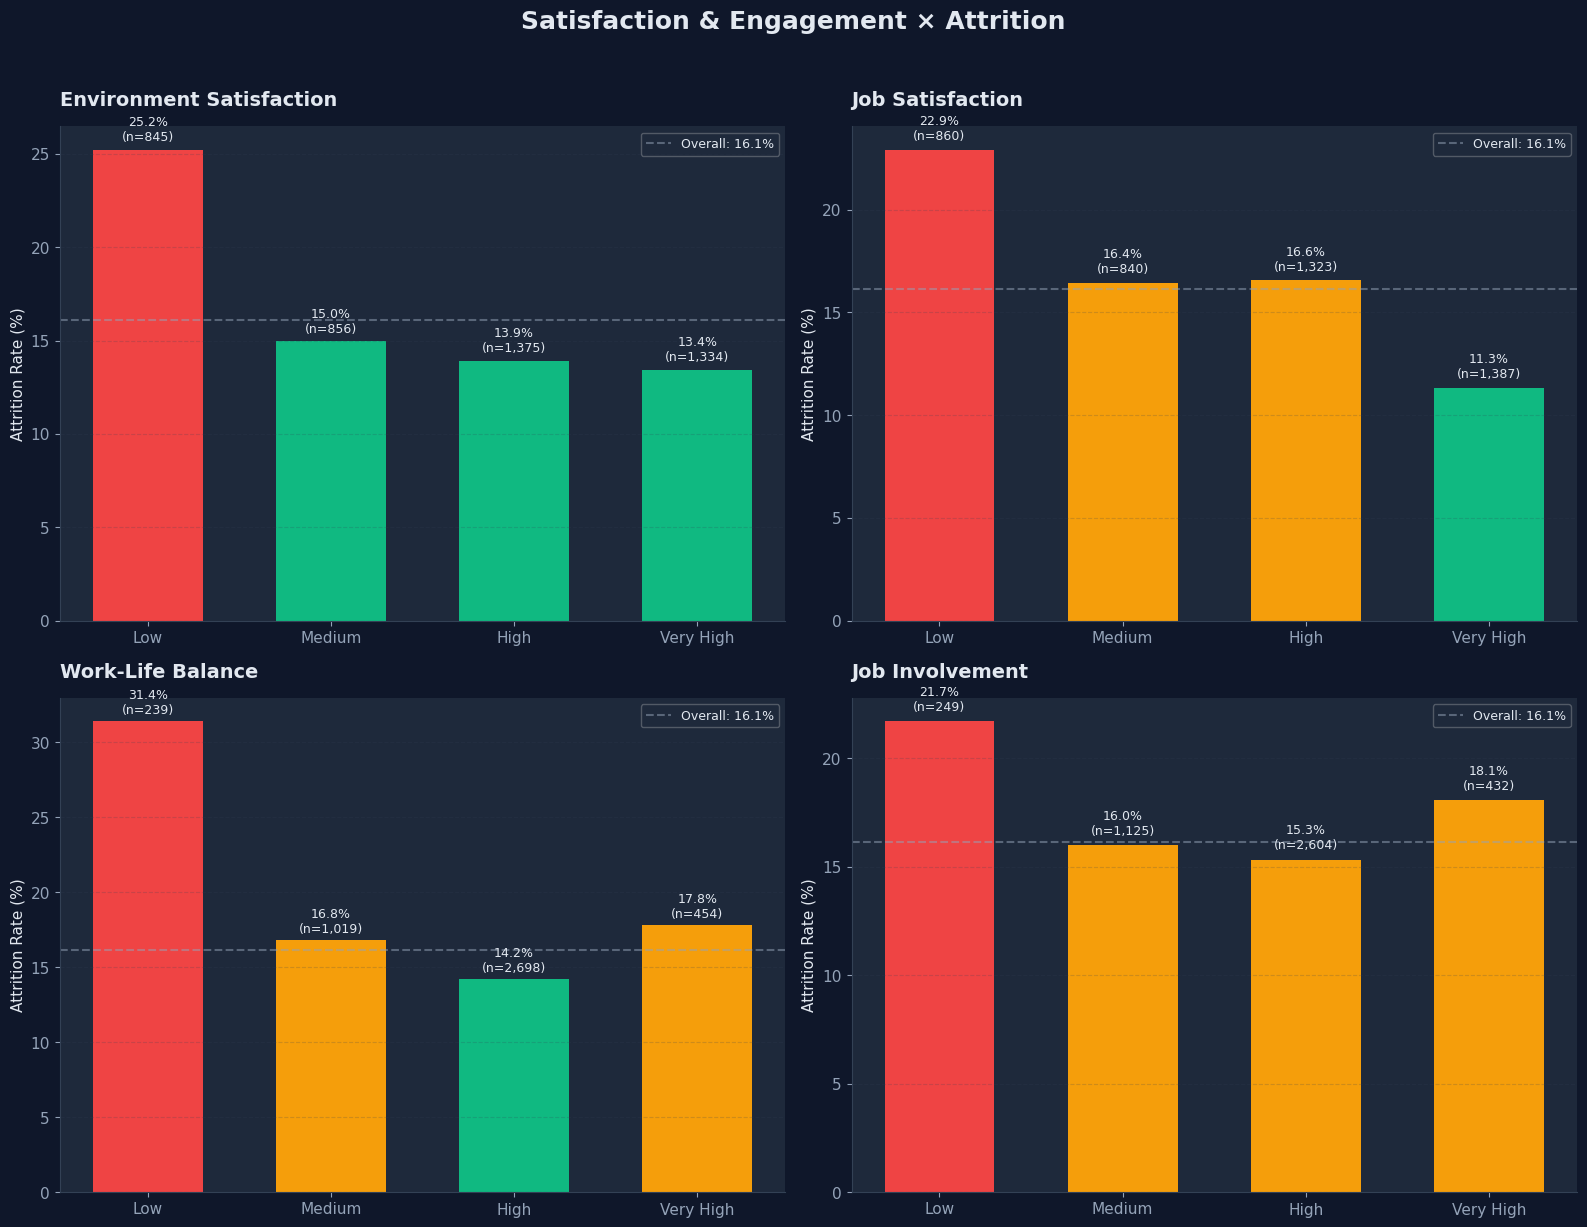

In [7]:
# Satisfaction metrics by attrition status
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Satisfaction & Engagement × Attrition', fontsize=18, fontweight='bold', y=1.02)

satisfaction_vars = [
    ('EnvironmentSatisfaction', 'Environment Satisfaction'),
    ('JobSatisfaction', 'Job Satisfaction'),
    ('WorkLifeBalance', 'Work-Life Balance'),
    ('JobInvolvement', 'Job Involvement')
]

level_labels = {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'}

for ax, (var, title) in zip(axes.flat, satisfaction_vars):
    # Calculate attrition rate per level
    rates = df.groupby(var)['AttritionFlag'].agg(['mean', 'count']).reset_index()
    rates.columns = [var, 'Rate', 'Count']
    rates['Rate'] = rates['Rate'] * 100
    rates['Label'] = rates[var].map(level_labels)
    
    colors = [COLORS['danger'] if r > 20 else COLORS['warning'] if r > 15 else COLORS['success']
              for r in rates['Rate']]
    bars = ax.bar(rates['Label'], rates['Rate'], color=colors, edgecolor='none', width=0.6)
    for bar, rate, count in zip(bars, rates['Rate'], rates['Count']):
        ax.text(bar.get_x() + bar.get_width()/2, rate + 0.5, f'{rate:.1f}%\n(n={count:,})', 
                ha='center', fontsize=9, color=COLORS['text'])
    
    ax.axhline(overall_rate, color=COLORS['muted'], linestyle='--', alpha=0.5,
               label=f'Overall: {overall_rate:.1f}%')
    format_ax(ax, title, '', 'Attrition Rate (%)')
    ax.legend(framealpha=0.3, fontsize=9)

plt.tight_layout()
plt.savefig('../reports/attrition_satisfaction.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

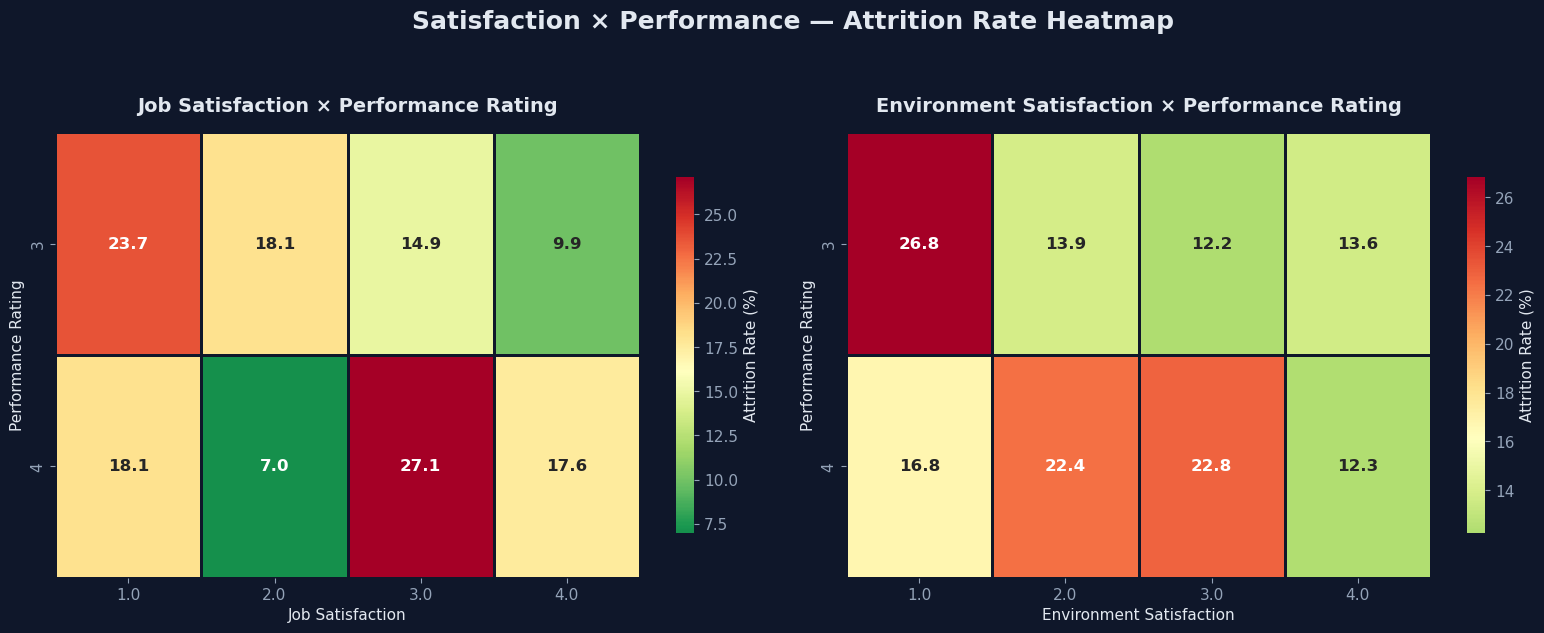

In [8]:
# Heatmap: Satisfaction × Performance × Attrition
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Satisfaction × Performance — Attrition Rate Heatmap', fontsize=18, fontweight='bold', y=1.05)

for ax, (sat_var, sat_title) in zip(axes, [
    ('JobSatisfaction', 'Job Satisfaction'),
    ('EnvironmentSatisfaction', 'Environment Satisfaction')
]):
    pivot = df.pivot_table(
        values='AttritionFlag', index='PerformanceRating', columns=sat_var,
        aggfunc='mean'
    ) * 100
    
    sns.heatmap(
        pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', center=overall_rate,
        linewidths=1, linecolor=COLORS['bg'], ax=ax,
        cbar_kws={'label': 'Attrition Rate (%)', 'shrink': 0.8},
        annot_kws={'size': 12, 'fontweight': 'bold'}
    )
    ax.set_title(f'{sat_title} × Performance Rating', fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Performance Rating')
    ax.set_xlabel(sat_title)

plt.tight_layout()
plt.savefig('../reports/attrition_heatmap.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

---
## 5. Promotion Stagnation & Development

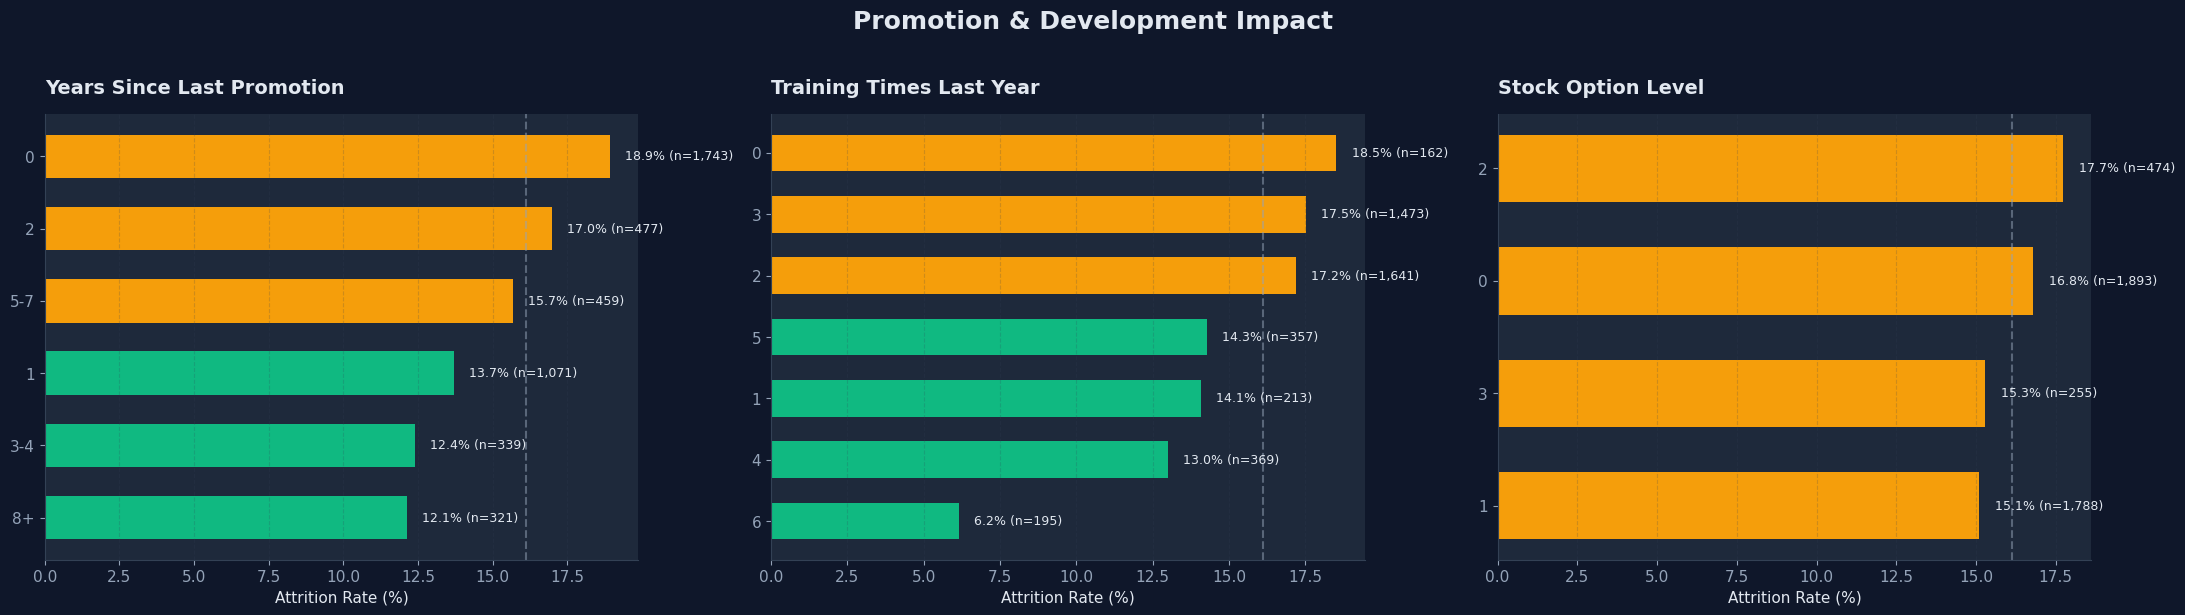

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Promotion & Development Impact', fontsize=18, fontweight='bold', y=1.02)

# ── Promotion stagnation ──
ax = axes[0]
promo_bins = [0, 1, 2, 3, 5, 8, 20]
promo_labels = ['0', '1', '2', '3-4', '5-7', '8+']
df['PromoGroup'] = pd.cut(df['YearsSinceLastPromotion'], bins=promo_bins, labels=promo_labels, right=False)
attrition_rate_by(df, 'PromoGroup', ax, 'Years Since Last Promotion')

# ── Training impact ──
ax = axes[1]
attrition_rate_by(df, 'TrainingTimesLastYear', ax, 'Training Times Last Year')

# ── Stock option impact ──
ax = axes[2]
attrition_rate_by(df, 'StockOptionLevel', ax, 'Stock Option Level')

plt.tight_layout()
plt.savefig('../reports/attrition_promo_dev.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

---
## 6. Financial Impact of Turnover

In [10]:
# Estimate turnover costs using industry benchmarks
# Entry-level (L1-L2): 50% of annual salary
# Mid-level (L3): 100% of annual salary  
# Senior (L4-L5): 200% of annual salary

cost_multiplier = {1: 0.5, 2: 0.5, 3: 1.0, 4: 2.0, 5: 2.0}

attrited_df = df[df['AttritionFlag'] == 1].copy()
attrited_df['AnnualSalary'] = attrited_df['MonthlyIncome'] * 12
attrited_df['ReplacementCost'] = attrited_df.apply(
    lambda row: row['AnnualSalary'] * cost_multiplier.get(row['JobLevel'], 1.0), axis=1
)

total_cost = attrited_df['ReplacementCost'].sum()
avg_cost = attrited_df['ReplacementCost'].mean()

print('=' * 50)
print('ESTIMATED TURNOVER COST')
print('=' * 50)
print(f'Total employees who left: {len(attrited_df):,}')
print(f'Total estimated replacement cost: {total_cost:,.0f}')
print(f'Average cost per departure: {avg_cost:,.0f}')
print(f'\n--- Breakdown by Job Level ---')
level_costs = attrited_df.groupby('JobLevel').agg(
    Count=('EmployeeID', 'count'),
    AvgSalary=('MonthlyIncome', 'mean'),
    TotalCost=('ReplacementCost', 'sum')
).round(0)
level_costs['CostMultiplier'] = level_costs.index.map(cost_multiplier)
print(level_costs.to_string())

print(f'\n--- Breakdown by Department ---')
dept_costs = attrited_df.groupby('Department').agg(
    Count=('EmployeeID', 'count'),
    TotalCost=('ReplacementCost', 'sum'),
    AttritionRate=('AttritionFlag', 'count')
).round(0)
print(dept_costs.to_string())

ESTIMATED TURNOVER COST
Total employees who left: 711
Total estimated replacement cost: 380,131,740
Average cost per departure: 534,644

--- Breakdown by Job Level ---
          Count  AvgSalary    TotalCost  CostMultiplier
JobLevel                                               
1           252    57646.0   87160860.0             0.5
2           285    69194.0  118322280.0             0.5
3            96    48586.0   55971000.0             1.0
4            51    69781.0   85411440.0             2.0
5            27    51337.0   33266160.0             2.0

--- Breakdown by Department ---
                        Count    TotalCost  AttritionRate
Department                                               
Human Resources            57   36222120.0             57
Research & Development    453  231823260.0            453
Sales                     201  112086360.0            201


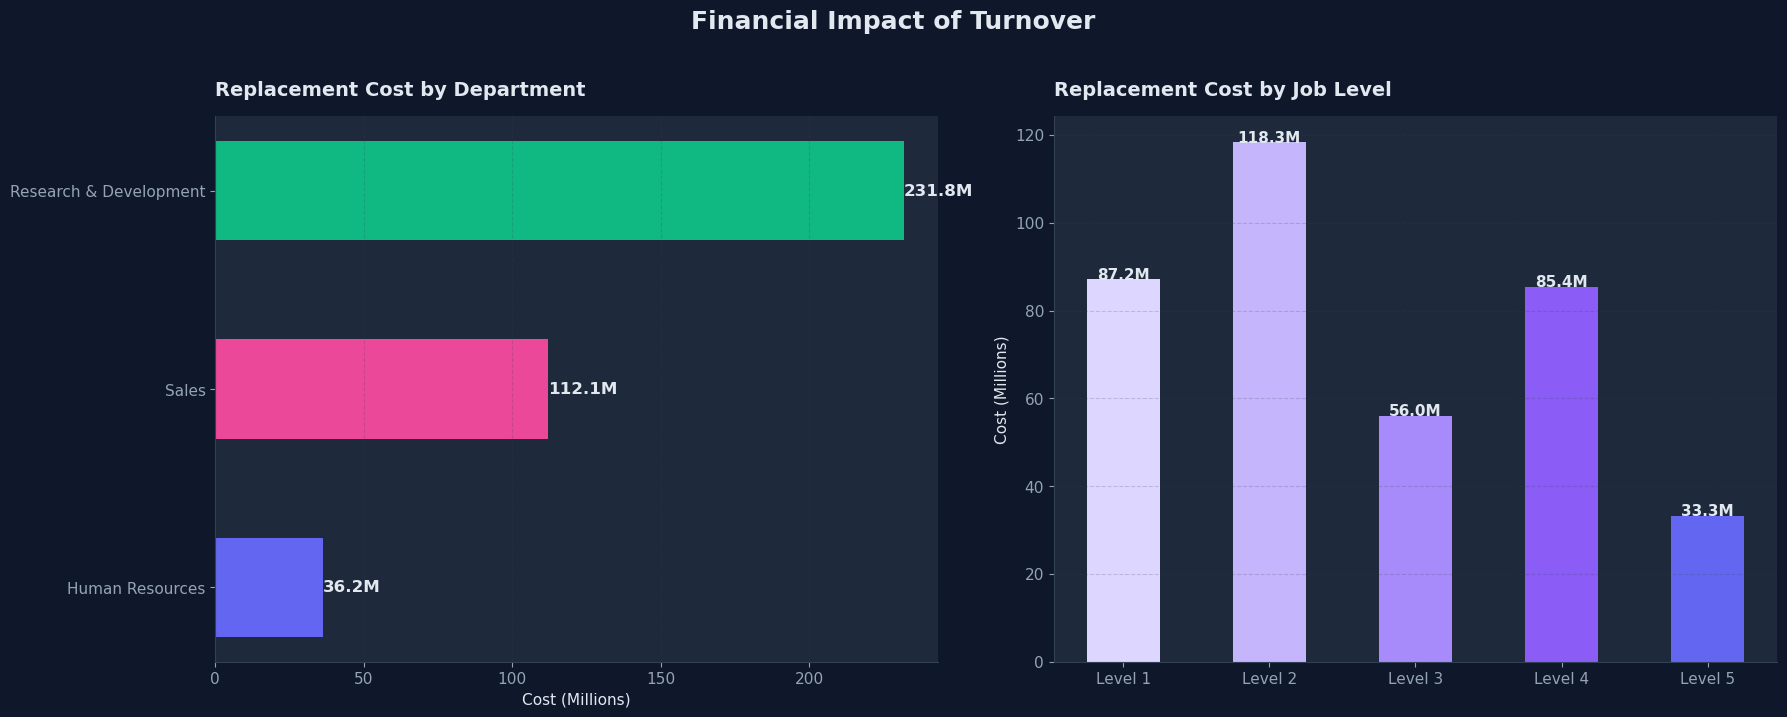

In [11]:
# Turnover cost visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Financial Impact of Turnover', fontsize=18, fontweight='bold', y=1.02)

# ── Cost by Department ──
ax = axes[0]
dept_cost = attrited_df.groupby('Department')['ReplacementCost'].sum().sort_values()
bars = ax.barh(dept_cost.index, dept_cost.values / 1e6, color=PALETTE_CAT[:3], edgecolor='none', height=0.5)
for bar, val in zip(bars, dept_cost.values):
    ax.text(val/1e6 + 0.05, bar.get_y() + bar.get_height()/2, f'{val/1e6:.1f}M', 
            va='center', fontsize=12, fontweight='bold', color=COLORS['text'])
format_ax(ax, 'Replacement Cost by Department', 'Cost (Millions)', '', grid_axis='x')

# ── Cost by Job Level ──
ax = axes[1]
level_cost = attrited_df.groupby('JobLevel')['ReplacementCost'].sum().sort_index()
bars = ax.bar([f'Level {l}' for l in level_cost.index], level_cost.values / 1e6, 
              color=['#6366F1', '#8B5CF6', '#A78BFA', '#C4B5FD', '#DDD6FE'][::-1], 
              edgecolor='none', width=0.5)
for bar, val in zip(bars, level_cost.values):
    ax.text(bar.get_x() + bar.get_width()/2, val/1e6 + 0.02, f'{val/1e6:.1f}M', 
            ha='center', fontsize=11, fontweight='bold', color=COLORS['text'])
format_ax(ax, 'Replacement Cost by Job Level', '', 'Cost (Millions)')

plt.tight_layout()
plt.savefig('../reports/turnover_cost.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

---
## 7. Top Drivers of Attrition — Summary

In [12]:
# Calculate attrition rate for all categorical and binned variables
drivers = {}

categorical_cols = ['Department', 'JobRole', 'BusinessTravel', 'Gender', 'MaritalStatus',
                    'EducationField', 'TenureGroup', 'AgeGroup', 'IncomeQuartile']

for col in categorical_cols:
    group_rates = df.groupby(col)['AttritionFlag'].mean() * 100
    max_rate = group_rates.max()
    min_rate = group_rates.min()
    spread = max_rate - min_rate
    max_group = group_rates.idxmax()
    drivers[col] = {
        'Spread (pp)': round(spread, 1),
        'Highest Risk Group': f'{max_group} ({max_rate:.1f}%)',
        'Lowest Risk Group': f'{group_rates.idxmin()} ({min_rate:.1f}%)'
    }

drivers_df = pd.DataFrame(drivers).T.sort_values('Spread (pp)', ascending=False)

print('=== ATTRITION DRIVERS — RANKED BY SPREAD ===')
print('(Spread = difference between highest and lowest attrition rate within the variable)')
print()
print(drivers_df.to_string())

=== ATTRITION DRIVERS — RANKED BY SPREAD ===
(Spread = difference between highest and lowest attrition rate within the variable)

               Spread (pp)         Highest Risk Group               Lowest Risk Group
AgeGroup              30.0              18-24 (39.2%)                    45-49 (9.2%)
EducationField        29.4    Human Resources (40.7%)        Technical Degree (11.4%)
TenureGroup           26.0           < 1 year (36.4%)               10+ years (10.4%)
BusinessTravel        16.9  Travel_Frequently (24.9%)               Non-Travel (8.0%)
MaritalStatus         15.4             Single (25.5%)                Divorced (10.1%)
Department            15.1    Human Resources (30.2%)                   Sales (15.0%)
JobRole               12.7  Research Director (23.8%)  Manufacturing Director (11.0%)
IncomeQuartile         4.2                 Q3 (17.6%)               Q4 (High) (13.4%)
Gender                 1.4               Male (16.7%)                  Female (15.3%)


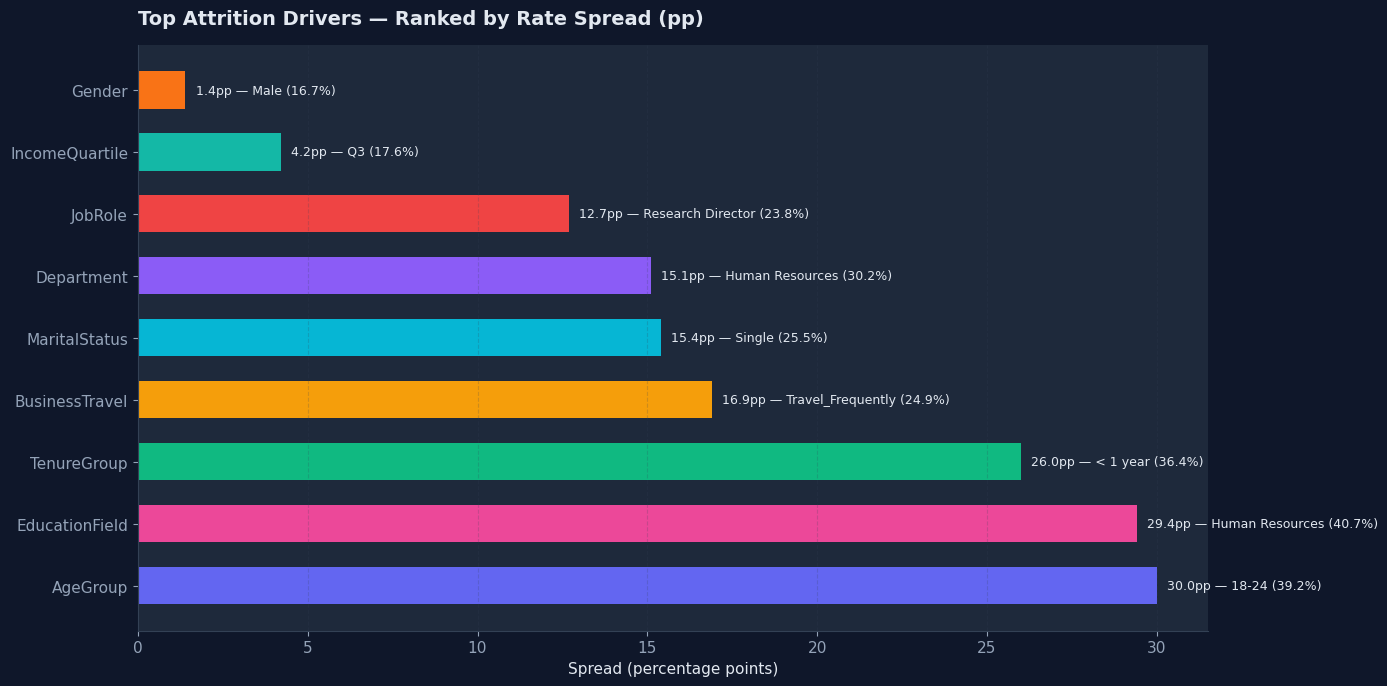

In [13]:
# Visual summary: Top drivers ranked
fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.barh(
    drivers_df.index, 
    drivers_df['Spread (pp)'], 
    color=PALETTE_CAT[:len(drivers_df)],
    edgecolor='none', 
    height=0.6
)

for bar, (idx, row) in zip(bars, drivers_df.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
            f'{row["Spread (pp)"]}pp — {row["Highest Risk Group"]}', 
            va='center', fontsize=9, color=COLORS['text'])

format_ax(ax, 'Top Attrition Drivers — Ranked by Rate Spread (pp)', 'Spread (percentage points)', '', grid_axis='x')

plt.tight_layout()
plt.savefig('../reports/attrition_drivers_ranked.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

---
## 8. Actionable Recommendations

Based on our analysis, here are the top 5 evidence-based recommendations:

### 🔴 Critical — Immediate Action

1. **Travel Policy Review**: Employees who travel frequently show significantly higher attrition. Consider rotating travel assignments, offering travel premiums, or enabling remote participation for frequent travelers.

2. **Early Tenure Retention Program**: New employees (< 1 year) and those in the 1-3 year range show elevated attrition. Implement structured onboarding, 90-day check-ins, and mentorship programs to increase early engagement.

### 🟡 Important — Medium-Term Initiatives

3. **Compensation Competitiveness**: Lower-income employees (Q1 within their level) are more likely to leave. Conduct market benchmarking and adjust compensation for roles below market median, especially at Level 1.

4. **Career Development Pathways**: Promotion stagnation (5+ years without promotion) correlates with higher attrition. Create transparent career ladders, lateral mobility options, and skill-based advancement criteria.

### 🟢 Strategic — Long-Term Investment

5. **Engagement Monitoring System**: Implement pulse surveys and track behavioral indicators (attendance patterns, work hours changes) to detect disengagement before it converts to resignation. The data shows that declining work hours precede attrition.